# 📊 속성 추출 결과 분석 및 시각화 대시보드

이 노트북은 `IP_속성.json`과 `제품_속성.json` 데이터를 불러와 추출 품질을 검토하고 키워드 분포를 분석합니다.

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 경로 설정 (src/data_builder/ 기준)
BASE_DIR = "../../data/processed/IP_속성추출"
IP_PATH = os.path.join(BASE_DIR, "IP_속성.json")
PROD_PATH = os.path.join(BASE_DIR, "제품_속성.json")

## 1. 데이터 로드 및 요약

In [2]:
with open(IP_PATH, 'r', encoding='utf-8') as f:
    ip_df = pd.DataFrame(json.load(f))

with open(PROD_PATH, 'r', encoding='utf-8') as f:
    prod_df = pd.DataFrame(json.load(f))

print(f"✅ 로드 완료!")
print(f"- IP 속성 데이터: {len(ip_df)}건")
print(f"- 제품 속성 데이터: {len(prod_df)}건")

✅ 로드 완료!
- IP 속성 데이터: 285건
- 제품 속성 데이터: 447건


## 2. 카테고리별 상위 키워드 시각화

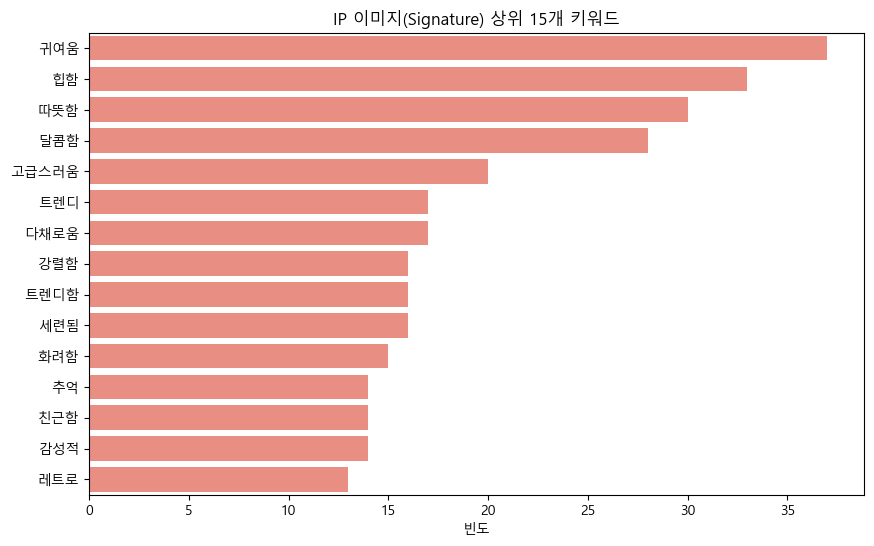

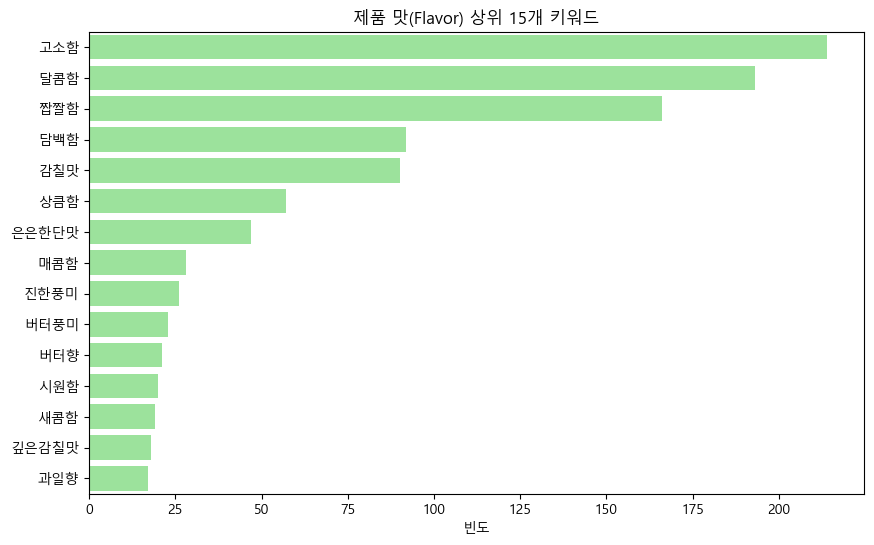

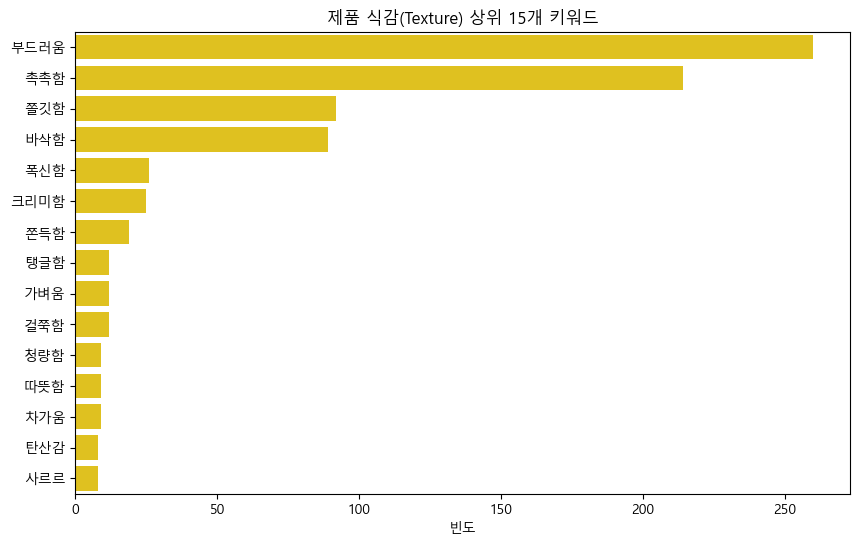

In [3]:
def plot_top_keywords(df, column, title, color='skyblue'):
    all_kws = []
    for kws in df[column].dropna():
        if isinstance(kws, list): all_kws.extend(kws)
        elif isinstance(kws, str): all_kws.append(kws)
    
    if not all_kws:
        print(f"[-] {title} 에 데이터가 없습니다.")
        return
        
    top_n = Counter(all_kws).most_common(15)
    k, v = zip(*top_n)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(v), y=list(k), color=color)
    plt.title(f"{title} 상위 15개 키워드")
    plt.xlabel("빈도")
    plt.show()

try:
    # IP 시그니처 키워드
    plot_top_keywords(ip_df, 'signature_keywords', 'IP 이미지(Signature)', color='salmon')

    # 제품 맛 키워드
    plot_top_keywords(prod_df, 'flavor', '제품 맛(Flavor)', color='lightgreen')

    # 제품 식감 키워드
    plot_top_keywords(prod_df, 'texture', '제품 식감(Texture)', color='gold')
except Exception as e:
    print(f"⚠️ 시각화 중 오류 발생 (데이터가 아직 충분하지 않을 수 있습니다): {e}")

## 3. 키워드 검색기

In [4]:
def search_keyword(query):
    ip_res = ip_df[ip_df['keyword'].str.contains(query, case=False)] if not ip_df.empty else pd.DataFrame()
    prod_res = prod_df[prod_df['keyword'].str.contains(query, case=False)] if not prod_df.empty else pd.DataFrame()
    
    if not ip_res.empty:
        print(f"\n🔍 IP 검색 결과 ({len(ip_res)}건):")
        display(ip_res[['keyword', 'ip_type', 'signature_keywords']].head(10))
        
    if not prod_res.empty:
        print(f"\n🔍 제품 검색 결과 ({len(prod_res)}건):")
        display(prod_res[['keyword', 'product_category', 'flavor', 'texture']].head(10))
        
    if ip_res.empty and prod_res.empty:
        print(f"❌ '{query}'에 대한 검색 결과가 없습니다.")

search_keyword("초코")


🔍 IP 검색 결과 (1건):


,keyword,ip_type,signature_keywords
170,초코파이,브랜드·기타,"[초콜릿, 마시멜로, 국민간식, 달콤함, 추억, 포근함]"



🔍 제품 검색 결과 (9건):


,keyword,product_category,flavor,texture
77,딥초코,스낵,"[진한초콜릿맛, 달콤함, 쌉싸름함]","[부드러움, 꾸덕함]"
102,리치초코,스낵,"[진한초콜릿맛, 달콤함, 고소함]","[부드러움, 촉촉함]"
136,민트초코,디저트,"[상큼함, 달콤함, 민트향]","[부드러움, 시원함]"
175,쁘띠초코,스낵,"[초콜릿맛, 달콤함, 진한풍미]","[부드러움, 사르르]"
326,초코쉘,스낵,"[초콜릿맛, 달콤함, 진한풍미]","[바삭함, 부드러움]"
327,초코우유,음료,"[달콤함, 고소함, 초콜릿풍미]","[부드러움, 크리미함]"
328,초코젤라또,아이스크림,"[달콤함, 초콜릿풍미, 진한풍미]","[부드러움, 크리미함]"
329,초코젤리,스낵,"[달콤함, 초콜릿풍미, 진한단맛]","[말랑함, 쫀득함]"
330,초코펜,스낵,"[초콜릿향, 달콤함, 진한풍미]","[바삭함, 부드러움]"


## 4. 네트워크 연결성 분석 (Bridge Keywords)
IP와 상품 양쪽에서 모두 발견되는 키워드를 찾습니다. 이 단어들이 네트워크를 잇는 핵심 노드가 됩니다.

In [5]:
ip_all_kws = set()
if 'signature_keywords' in ip_df.columns:
    for kws in ip_df['signature_keywords'].dropna():
        if isinstance(kws, list): ip_all_kws.update(kws)

prod_all_kws = set()
for col in ['flavor', 'texture', 'tpo']:
    if col in prod_df.columns:
        for kws in prod_df[col].dropna():
            if isinstance(kws, list): prod_all_kws.update(kws)

bridge_kws = ip_all_kws.intersection(prod_all_kws)
print(f"🌉 발견된 브릿지 키워드 수: {len(bridge_kws)}개")
if bridge_kws:
    print(f"주요 브릿지 예시: {sorted(list(bridge_kws))[:20]}")
else:
    print("💡 아직 공통 키워드가 발견되지 않았습니다. 배치가 완료된 후 다시 확인하세요.")

🌉 발견된 브릿지 키워드 수: 39개
주요 브릿지 예시: ['간식', '간편식', '감칠맛', '건강관리', '고소함', '깔끔함', '꾸덕함', '달콤함', '담백함', '디저트', '따뜻함', '맑음', '매운맛', '매콤함', '묵직함', '바닐라', '바삭함', '부드러움', '불맛', '브런치']
